CatBoost Model

In [2]:
pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Load data
X_train = pd.read_csv("../data/X_train_enc.csv")
X_test = pd.read_csv("../data/X_test_enc.csv")

y_train = pd.read_csv("../data/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/y_test.csv").values.ravel()

# Train CatBoost
cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    verbose=False
)

cat_model.fit(X_train, y_train)

# Predictions
cat_pred = cat_model.predict(X_test).astype(int).ravel()
cat_prob = cat_model.predict_proba(X_test)[:,1]

# Metrics
cat_results = {
    "model":"CatBoost",
    "accuracy":accuracy_score(y_test,cat_pred),
    "precision":precision_score(y_test,cat_pred),
    "recall":recall_score(y_test,cat_pred),
    "f1":f1_score(y_test,cat_pred),
    "roc_auc":roc_auc_score(y_test,cat_prob)
}

print(cat_results)

{'model': 'CatBoost', 'accuracy': 0.8741437108293252, 'precision': 0.8214390764026767, 'recall': 0.9856834024530133, 'f1': 0.8960973848868924, 'roc_auc': np.float64(0.9840532077453787)}


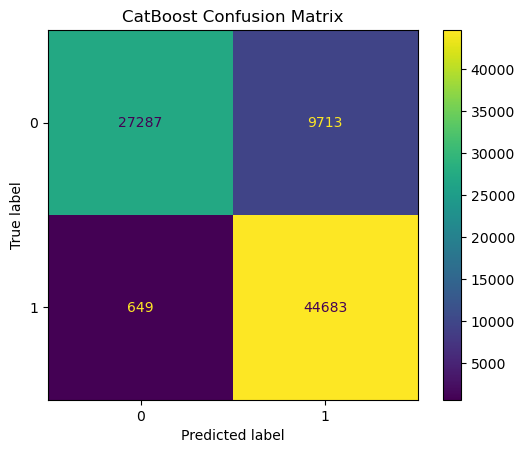

In [4]:
cm = confusion_matrix(y_test, cat_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("CatBoost Confusion Matrix")
plt.show()

Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

rf_results = {
    "model":"RandomForest",
    "accuracy":accuracy_score(y_test,rf_pred),
    "precision":precision_score(y_test,rf_pred),
    "recall":recall_score(y_test,rf_pred),
    "f1":f1_score(y_test,rf_pred),
    "roc_auc":roc_auc_score(y_test,rf_prob)
}

print(rf_results)

{'model': 'RandomForest', 'accuracy': 0.8708643054948259, 'precision': 0.8174283727908083, 'recall': 0.9855951645636636, 'f1': 0.8936693669366936, 'roc_auc': np.float64(0.979282002928544)}


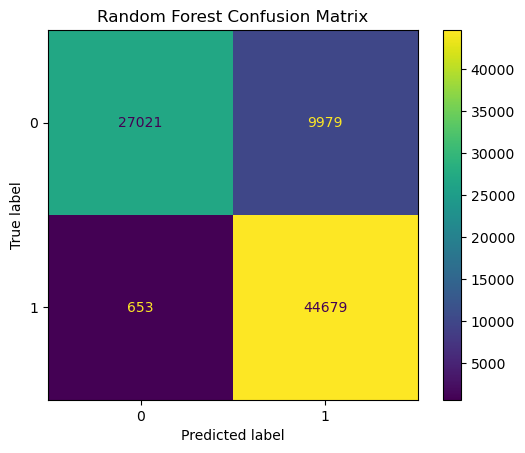

In [6]:
cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

Muti Layer Perceptron

In [7]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)
import matplotlib.pyplot as plt

# Load scaled data
X_train_scaled = np.load("../data/X_train_scaled.npy")
X_test_scaled = np.load("../data/X_test_scaled.npy")

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

In [9]:
class IDSNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [10]:
SEED = 42
torch.manual_seed(SEED)

nn_model = IDSNet(X_train_scaled.shape[1])

# Class weighting for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
pos_weight_value = neg_count / pos_count

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32)
)

optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001)

In [11]:
EPOCHS = 15

for epoch in range(EPOCHS):
    nn_model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()

        logits = nn_model(xb)
        loss = criterion(logits, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

Epoch 1/15, Loss: 0.1120
Epoch 2/15, Loss: 0.0900
Epoch 3/15, Loss: 0.0874
Epoch 4/15, Loss: 0.0869
Epoch 5/15, Loss: 0.0849
Epoch 6/15, Loss: 0.0848
Epoch 7/15, Loss: 0.0839
Epoch 8/15, Loss: 0.0836
Epoch 9/15, Loss: 0.0833
Epoch 10/15, Loss: 0.0829
Epoch 11/15, Loss: 0.0821
Epoch 12/15, Loss: 0.0820
Epoch 13/15, Loss: 0.0815
Epoch 14/15, Loss: 0.0813
Epoch 15/15, Loss: 0.0810


In [12]:
nn_model.eval()

with torch.no_grad():
    logits = nn_model(X_test_tensor)
    nn_prob = torch.sigmoid(logits).cpu().numpy().ravel()

thresholds = np.arange(0.10, 0.90, 0.01)

best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    preds = (nn_prob >= t).astype(int)
    score = f1_score(y_test, preds)

    if score > best_f1:
        best_f1 = score
        best_thresh = t

print("Best threshold:", round(best_thresh, 2))
print("Best F1:", round(best_f1, 4))

Best threshold: 0.65
Best F1: 0.9157


In [13]:
nn_pred = (nn_prob >= best_thresh).astype(int)

nn_results = {
    "model": "NeuralNet",
    "accuracy": accuracy_score(y_test, nn_pred),
    "precision": precision_score(y_test, nn_pred, zero_division=0),
    "recall": recall_score(y_test, nn_pred, zero_division=0),
    "f1": f1_score(y_test, nn_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, nn_prob)
}

print(nn_results)

{'model': 'NeuralNet', 'accuracy': 0.9072292668707186, 'precision': 0.9164346634849088, 'recall': 0.9149386746669019, 'f1': 0.915686058063804, 'roc_auc': np.float64(0.9772538970740793)}


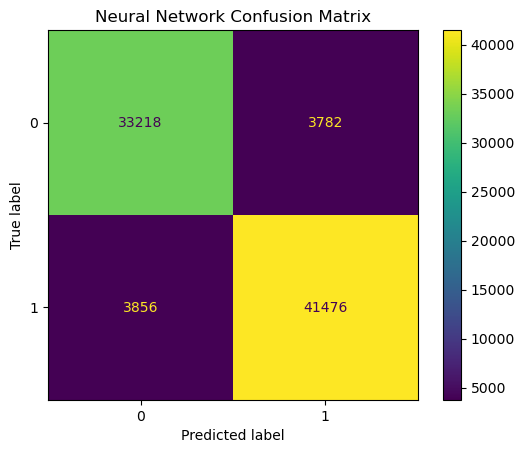

In [14]:
cm = confusion_matrix(y_test, nn_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Neural Network Confusion Matrix")
plt.show()

In [15]:
import pandas as pd
import os

os.makedirs("../results", exist_ok=True)

results_df = pd.DataFrame([
    cat_results,
    rf_results,
    nn_results
])

results_df.to_csv("../results/baselines.csv", index=False)

print(results_df)
print("Saved -> ../results/baselines.csv")

          model  accuracy  precision    recall        f1   roc_auc
0      CatBoost  0.874144   0.821439  0.985683  0.896097  0.984053
1  RandomForest  0.870864   0.817428  0.985595  0.893669  0.979282
2     NeuralNet  0.907229   0.916435  0.914939  0.915686  0.977254
Saved -> ../results/baselines.csv


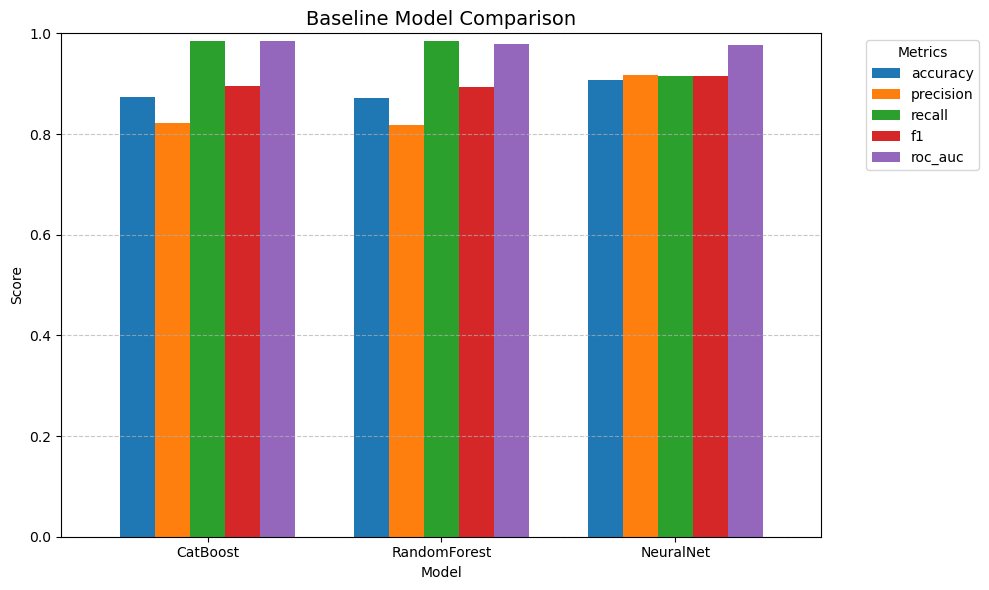

In [16]:
import matplotlib.pyplot as plt

metrics = ["accuracy","precision","recall","f1","roc_auc"]

ax = results_df.set_index("model")[metrics].plot(
    kind="bar",
    figsize=(10,6),   # bigger figure
    width=0.75        # thinner bars → more space
)

plt.title("Baseline Model Comparison", fontsize=14)
plt.ylabel("Score")
plt.xlabel("Model")

plt.xticks(rotation=0)
plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.legend(title="Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend OUTSIDE

plt.tight_layout()   # 🔥 VERY IMPORTANT (prevents cutting/overlap)

plt.show()

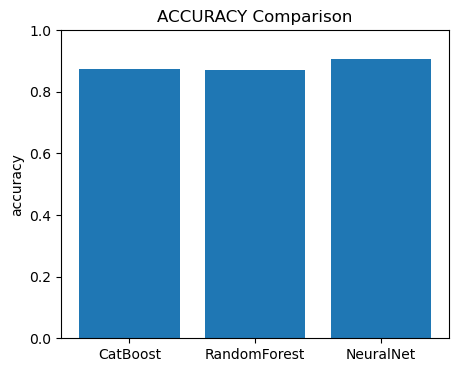

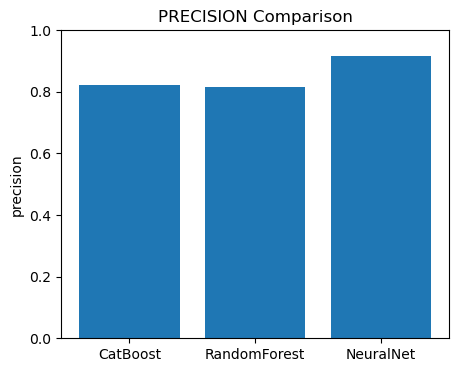

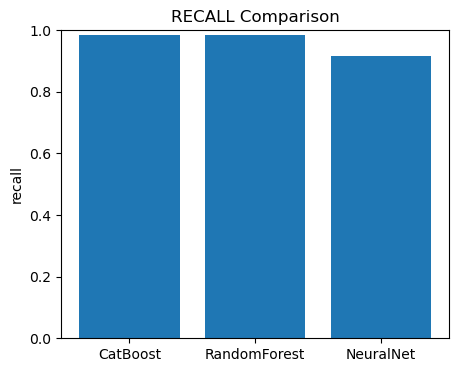

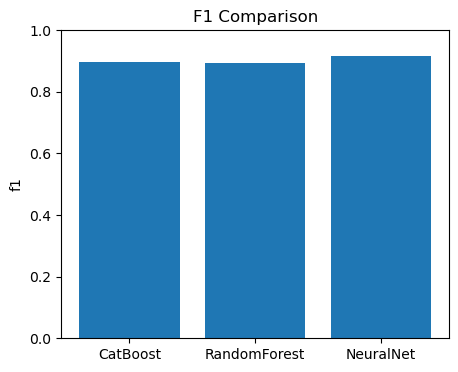

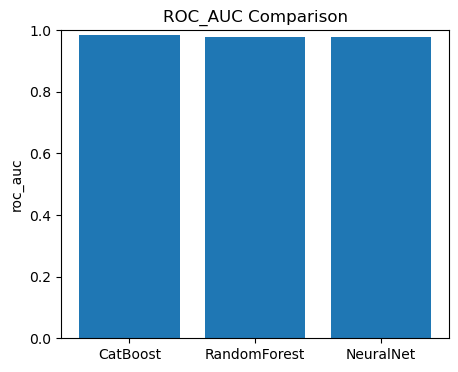

In [17]:
for metric in metrics:
    
    plt.figure(figsize=(5,4))
    
    plt.bar(results_df["model"], results_df[metric])
    
    plt.title(f"{metric.upper()} Comparison")
    
    plt.ylabel(metric)
    
    plt.ylim(0,1)
    
    plt.show()

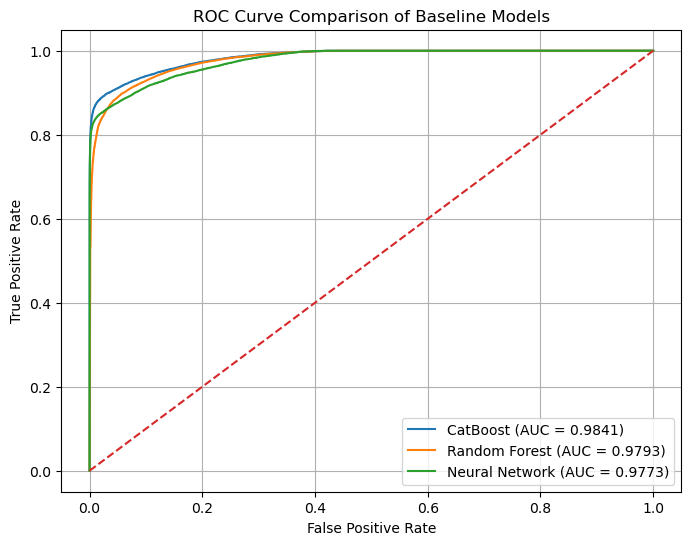

In [18]:
from sklearn.metrics import roc_curve, auc

fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_prob)

auc_cat = auc(fpr_cat, tpr_cat)
auc_rf = auc(fpr_rf, tpr_rf)
auc_nn = auc(fpr_nn, tpr_nn)

plt.figure(figsize=(8, 6))

plt.plot(fpr_cat, tpr_cat, label=f"CatBoost (AUC = {auc_cat:.4f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.4f})")
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {auc_nn:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Baseline Models")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import pandas as pd
import os

os.makedirs("../results", exist_ok=True)

pd.DataFrame({
    "y_true": y_test,
    "y_prob": cat_prob
}).to_csv("../results/catboost_predictions.csv", index=False)

pd.DataFrame({
    "y_true": y_test,
    "y_prob": rf_prob
}).to_csv("../results/randomforest_predictions.csv", index=False)

pd.DataFrame({
    "y_true": y_test,
    "y_prob": nn_prob
}).to_csv("../results/neuralnet_predictions.csv", index=False)

print("Saved CatBoost, Random Forest, and Neural Network prediction files.")

Saved CatBoost, Random Forest, and Neural Network prediction files.
